In [6]:
# kMeans: K개의 평균들
#   비지도학습
#   군집화(클러스터링): 비슷한 것끼리 묶음
#   1) 데이터를 그래프에 다 표시
#   2) (k=2)라고 지정했다면 (2그룹으로 나누라고 했다면) 랜덤한 점 2개 그래프에 표시
#   3) 2번에서 찍은 점과 데이터들과의 거리 계산
#   4) 가까운 쪽으로 그룹화
#   5) 그룹 내에서 평균내서 그 위치에 점 표시
#   6) 5번에서 찍은 점과 데이터들과의 거리 계산
#   7) 가까운 쪽으로 그룹화
#`  5~7 반복 -> 그룹 변화가 없을 때까지 반복

In [2]:
# subway.csv
import pandas as pd

subwayDF = pd.read_csv("/home/azureuser/cloudfiles/code/Users/stu_ict01_01/May29_1_MachineLearning/subway.csv",
                       names=["년", "월", "일", "노선", "역", "타고", "내리고"])
subwayDF = subwayDF.groupby("역")[["타고", "내리고"]].mean() # 역별 타고, 내리고 평균
print(subwayDF)
print(subwayDF.loc["종각"])

                     타고           내리고
역                                    
4.19민주묘지    2994.794623   2860.110530
가능          6761.949630   6417.983575
가락시장        7917.660964   8260.135368
가산디지털단지    26457.021489  27727.780044
가양         19658.998084  19004.231864
...                 ...           ...
회룡         12398.163154  12050.954010
회현         29231.298780  31101.428354
회현(남대문시장)  25301.806473  26577.192192
효창공원앞       4900.677760   4743.686996
흑석(중앙대입구)   9042.743225   9269.846701

[598 rows x 2 columns]
타고     38469.925267
내리고    36891.618670
Name: 종각, dtype: float64


In [3]:
# Matplotlib: Python 시각화 라이브러리
# Seaborn: Matplotlib을 편하게 쓰게 해주는 라이브러리
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [8]:
from sklearn.cluster import KMeans

feature = subwayDF[["타고", "내리고"]].to_numpy()

km = KMeans(3)

subwayDF["그룹"] = km.fit_predict(feature)
print(subwayDF)

                     타고           내리고  그룹
역                                        
4.19민주묘지    2994.794623   2860.110530   0
가능          6761.949630   6417.983575   0
가락시장        7917.660964   8260.135368   0
가산디지털단지    26457.021489  27727.780044   1
가양         19658.998084  19004.231864   1
...                 ...           ...  ..
회룡         12398.163154  12050.954010   0
회현         29231.298780  31101.428354   1
회현(남대문시장)  25301.806473  26577.192192   1
효창공원앞       4900.677760   4743.686996   0
흑석(중앙대입구)   9042.743225   9269.846701   0

[598 rows x 3 columns]


<function matplotlib.pyplot.show(close=None, block=None)>

/anaconda/envs/jupyter_env/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 53440 (\N{HANGUL SYLLABLE TA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/anaconda/envs/jupyter_env/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/anaconda/envs/jupyter_env/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 45236 (\N{HANGUL SYLLABLE NAE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/anaconda/envs/jupyter_env/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/anaconda/envs/jupyter_env/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/anaconda/envs/jupyter_env/lib/python3.10/s

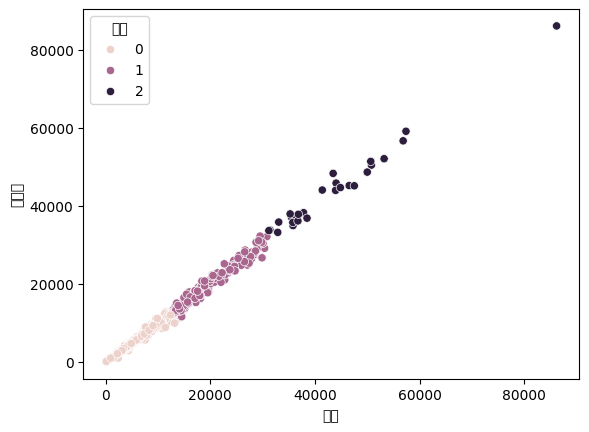

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(subwayDF, x="타고", y="내리고", hue="그룹")
plt.show